In [1]:
# Data frames & numbers
import pandas as pd
import numpy as np

# graphic visualitation 
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Data science
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Regression models
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classification models to predict churn rate
from sklearn.tree import DecisionTreeRegressor  
from sklearn.ensemble import RandomForestRegressor 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

# Clustering model ML
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

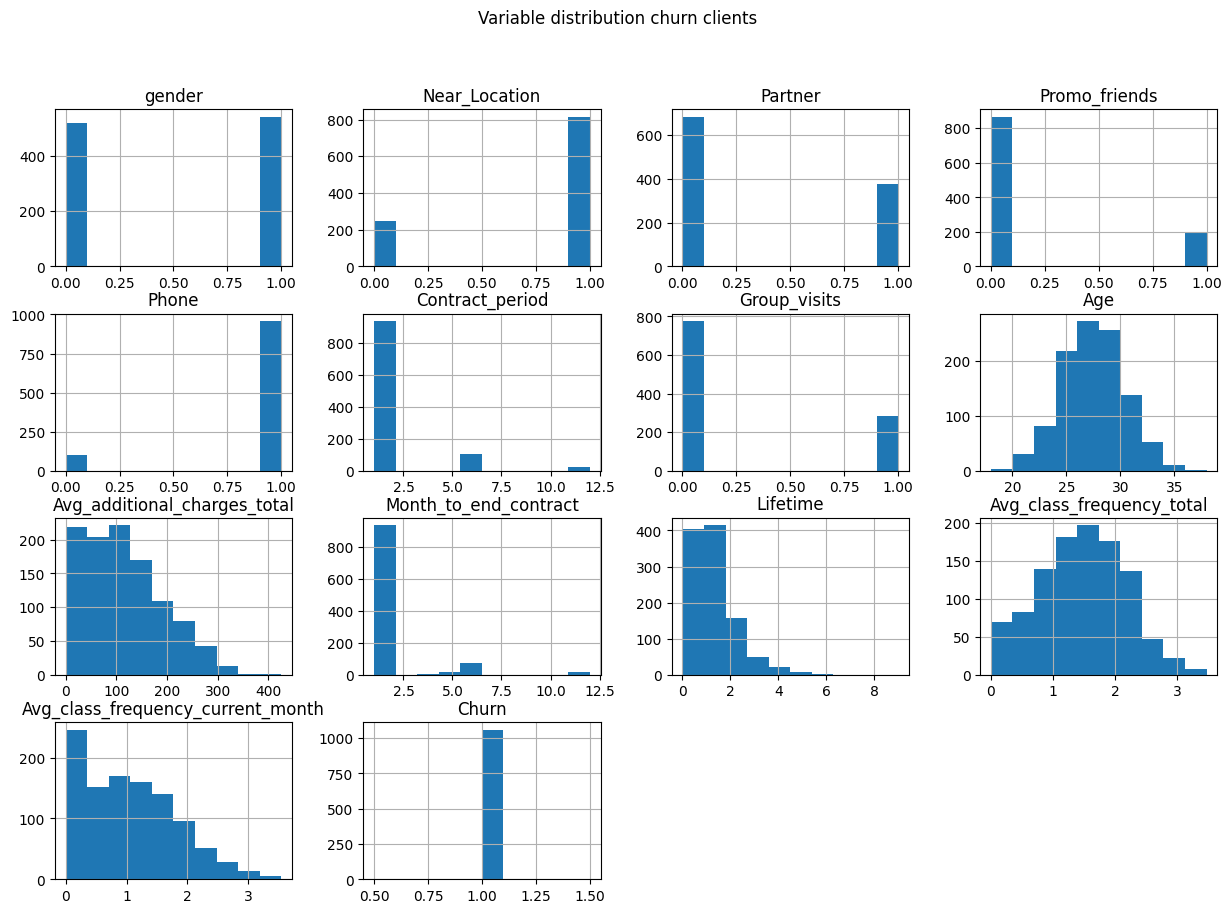

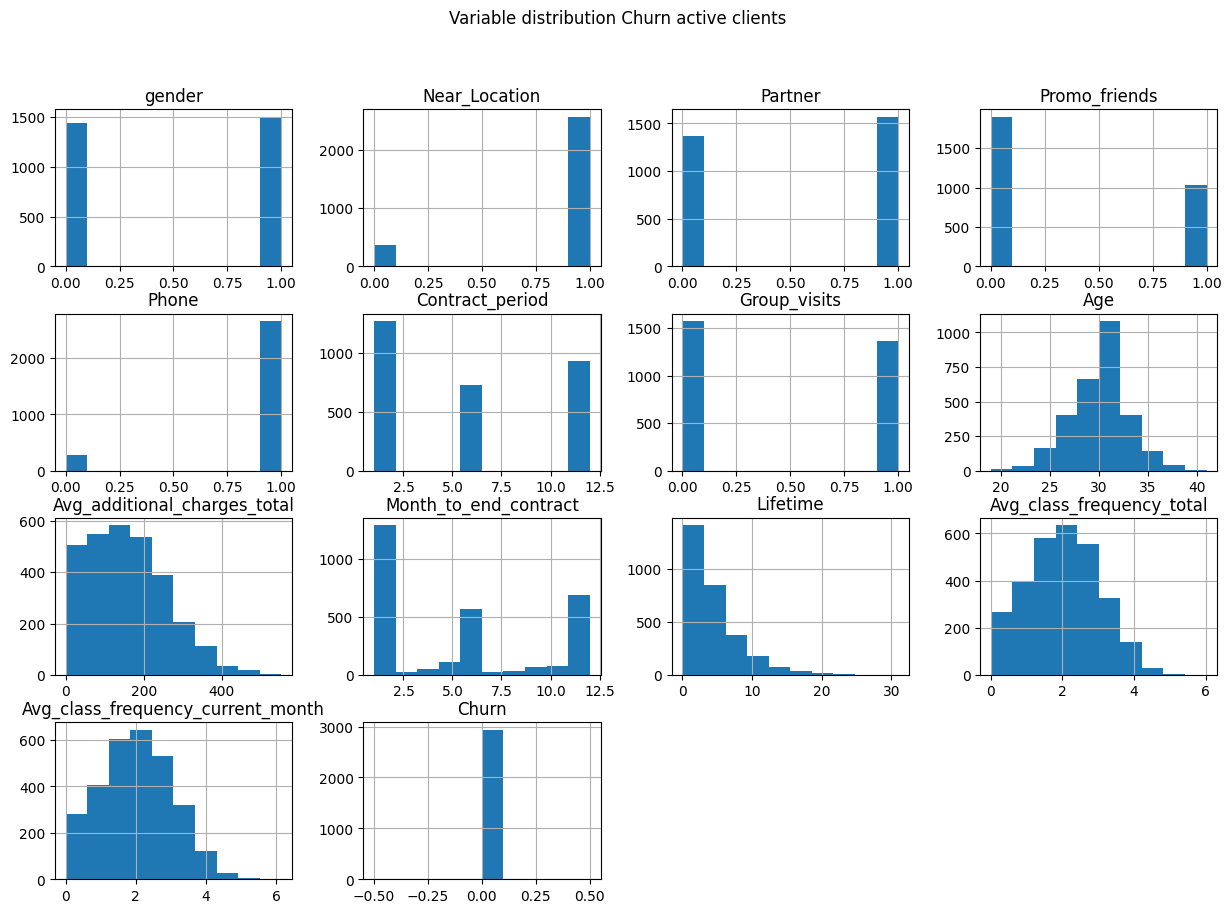

                                     gender  Near_Location   Partner  \
gender                             1.000000       0.011913  0.009509   
Near_Location                      0.011913       1.000000 -0.049416   
Partner                            0.009509      -0.049416  1.000000   
Promo_friends                     -0.012723       0.197275  0.379864   
Phone                             -0.008811      -0.021734 -0.022625   
Contract_period                    0.023992       0.058915  0.172161   
Group_visits                       0.027271       0.111250  0.016582   
Age                                0.017344       0.008065 -0.037490   
Avg_additional_charges_total       0.005232      -0.003562 -0.015331   
Month_to_end_contract              0.022929       0.061410  0.167682   
Lifetime                          -0.008307      -0.008687  0.025813   
Avg_class_frequency_total          0.002240       0.044960  0.001292   
Avg_class_frequency_current_month -0.015462       0.040668 -0.02

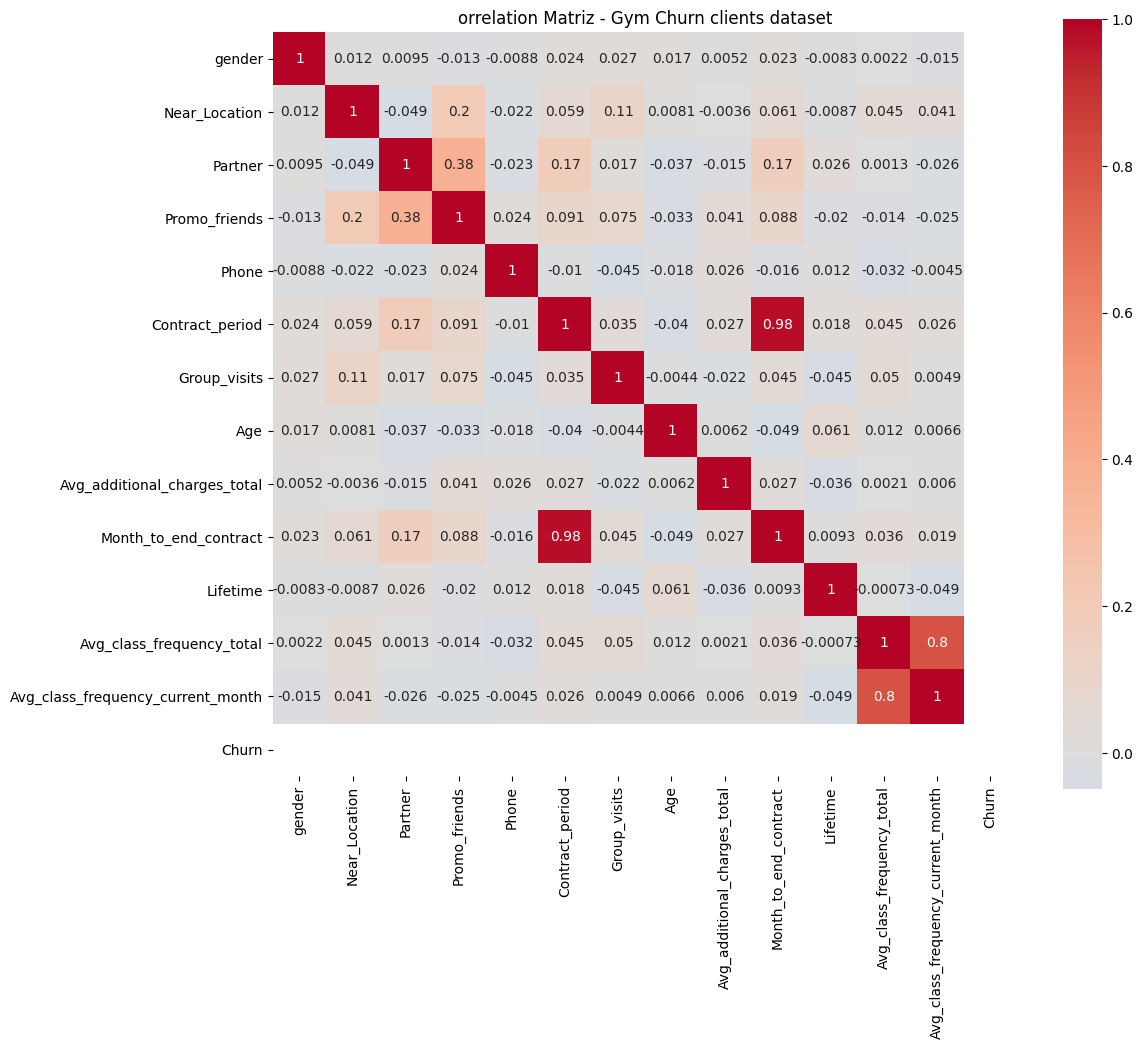

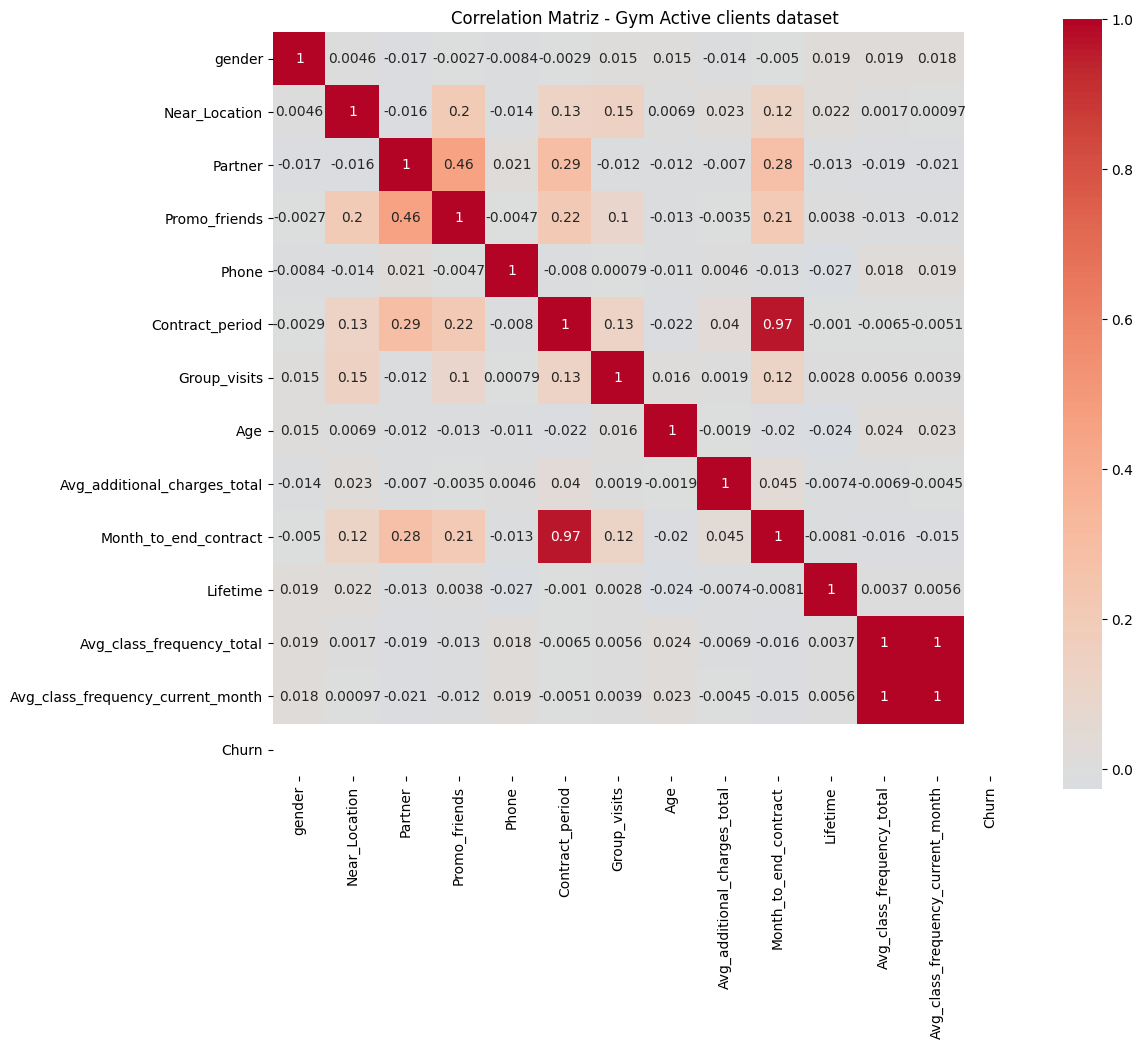

In [2]:
# Step 1 (Load data)
df = pd.read_csv('/datasets/gym_churn_us.csv')

# Step 2 EDA (exploratory data analysis)
print(df.info())
print(df.head())
print(df.describe())
print("Empty values:",df.isna().sum())
print(df.groupby('Churn').mean())
churn_clients = df[df['Churn'] == 1]
clients =  df[df['Churn'] == 0]

# Churn clients histogram
churn_clients.hist(figsize=(15, 10))
plt.suptitle('Variable distribution churn clients')
plt.show()

# Active clients histogram
clients.hist(figsize=(15, 10))
plt.suptitle('Variable distribution Churn active clients')
plt.show()

# Correlation matrix 
churn_corr = churn_clients.corr()
print(churn_corr)

clients_corr = clients.corr()
print(clients_corr)

# Heatmap churn clients 1
plt.figure(figsize=(12, 10))
sns.heatmap(churn_corr, 
            annot=True,           # show numbers
            cmap='coolwarm',      # Colors: blue=negative, red=positive
            center=0,             # Center in 0
            square=True)         
plt.title('orrelation Matriz - Gym Churn clients dataset')
plt.show()

# Heatmap clients 2
plt.figure(figsize=(12, 10))
sns.heatmap(clients_corr, 
            annot=True,           # show numbers
            cmap='coolwarm',      # Colors: blue = negative, red = positive
            center=0,             # Center in 0
            square=True)          
plt.title('Correlation Matriz - Gym Active clients dataset')
plt.show()

In [3]:
# Step 3 Preditive Binary Classificaiton model for Churn rate 
# I Variables assignment & data division 
X = df.drop('Churn', axis = 1)
y = df['Churn']

# data division (test & train)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# II Standarize data
scaler = StandardScaler()
scaler.fit(X_train)

X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

# III Train models
# 1. Regression model (Logistic regression)
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_st, y_train)

# Classificaction model (Random Forest)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_st, y_train)  

# IV Predictions
# Binary predictions (0/1)
lr_predictions = lr_model.predict(X_test_st)
rf_predictions = rf_model.predict(X_test_st)

# Positive probability of the class (churn = 1)
rf_probabilities = rf_model.predict_proba(X_test_st)[:,1]
lr_probabilities = lr_model.predict_proba(X_test_st)[:,1]

# V Metrics: function for all metrics
def print_all_metrics(y_true, y_pred, y_proba, title = 'Clasification metrics'):
    print(title)
    print('\tAccuracy: {:.2f}'.format(accuracy_score(y_true, y_pred)))
    print('\tPrecision: {:.2f}'.format(precision_score(y_true, y_pred)))
    print('\tRecall: {:.2f}'.format(recall_score(y_true, y_pred)))
    print('\tF1: {:.2f}'.format(f1_score(y_true, y_pred)))
    print('\tROC_AUC: {:.2f}'.format(roc_auc_score(y_true, y_proba)))

# Show all metrics
print_all_metrics(y_test, lr_predictions, lr_probabilities, title='Logistic Regression metrics:')
print_all_metrics(y_test, rf_predictions, rf_probabilities, title='Random Forest metrics:')


Logistic Regression metrics:
	Accuracy: 0.92
	Precision: 0.87
	Recall: 0.78
	F1: 0.83
	ROC_AUC: 0.97
Random Forest metrics:
	Accuracy: 0.91
	Precision: 0.85
	Recall: 0.78
	F1: 0.81
	ROC_AUC: 0.96


Analyzing the values obtained from the metrics of each of the models used to predict the probability of customer churn using the logical regression and random forest models. We can observe that, for this dataset with 4,000 records, the regression model performs slightly better than the random forest model. Regarding the recall evaluation metric, which gives us the sensitivity to identify true churns, this is more relevant for the business than the precision of finding them. This metric tells us how many of the predicted churns actually left. The practical implications are that if we prioritize recall over precision, we prefer to identify ALL at-risk customers and therefore accept some "false positives." In the case of the gym, this means contacting customers who don't leave therefore the cost of an extra call/email is less than losing a customer who is going to cancel. 

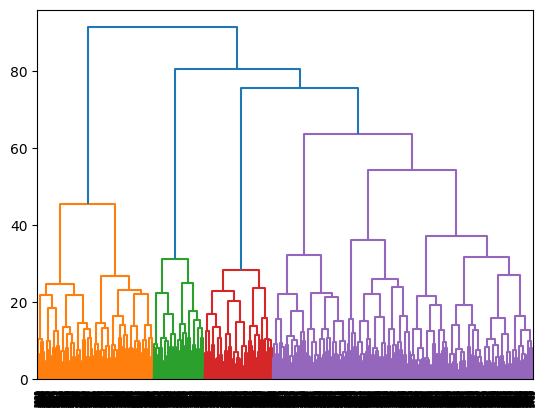

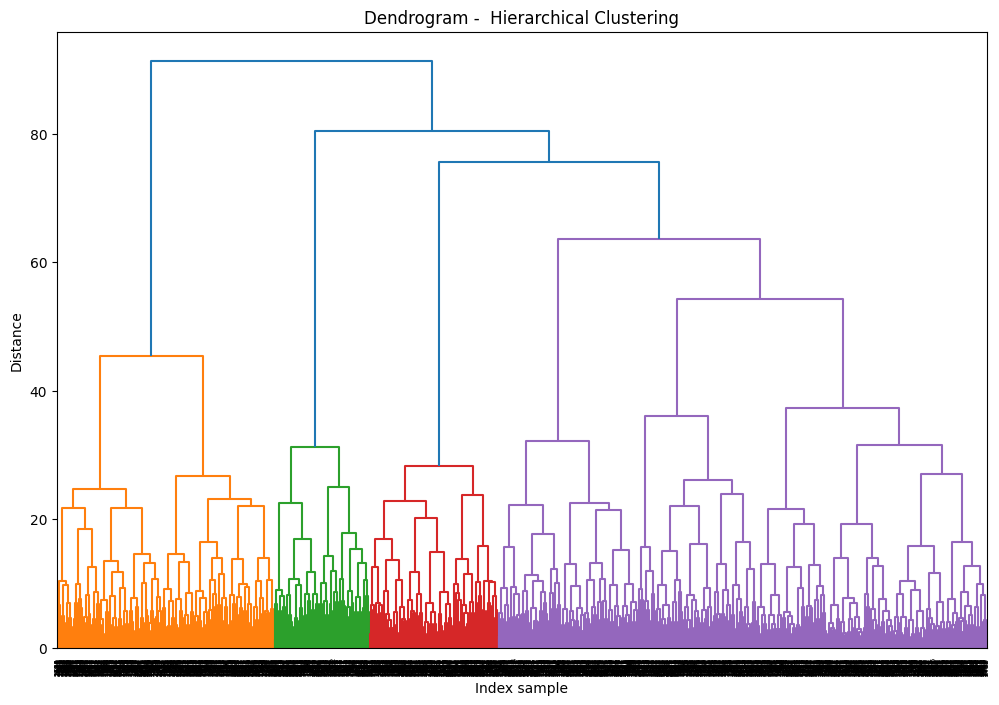

Silhouette score: 0.13
Valores medios por cluster:
           gender  Near_Location   Partner  Promo_friends     Phone  \
Cluster                                                               
0        0.524675       0.862338  0.470130       0.303896  0.000000   
1        0.499422       0.936416  0.738728       0.480925  0.998844   
2        0.553531       0.848519  0.267654       0.054670  1.000000   
3        0.500000       0.949527  0.823344       0.998423  1.000000   
4        0.487884       0.720517  0.298869       0.016155  1.000000   

         Contract_period  Group_visits        Age  \
Cluster                                             
0               4.758442      0.425974  29.288312   
1              11.847399      0.549133  29.898266   
2               2.651481      0.440774  30.061503   
3               3.078864      0.446372  29.088328   
4               1.910339      0.274637  28.079968   

         Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
Clust

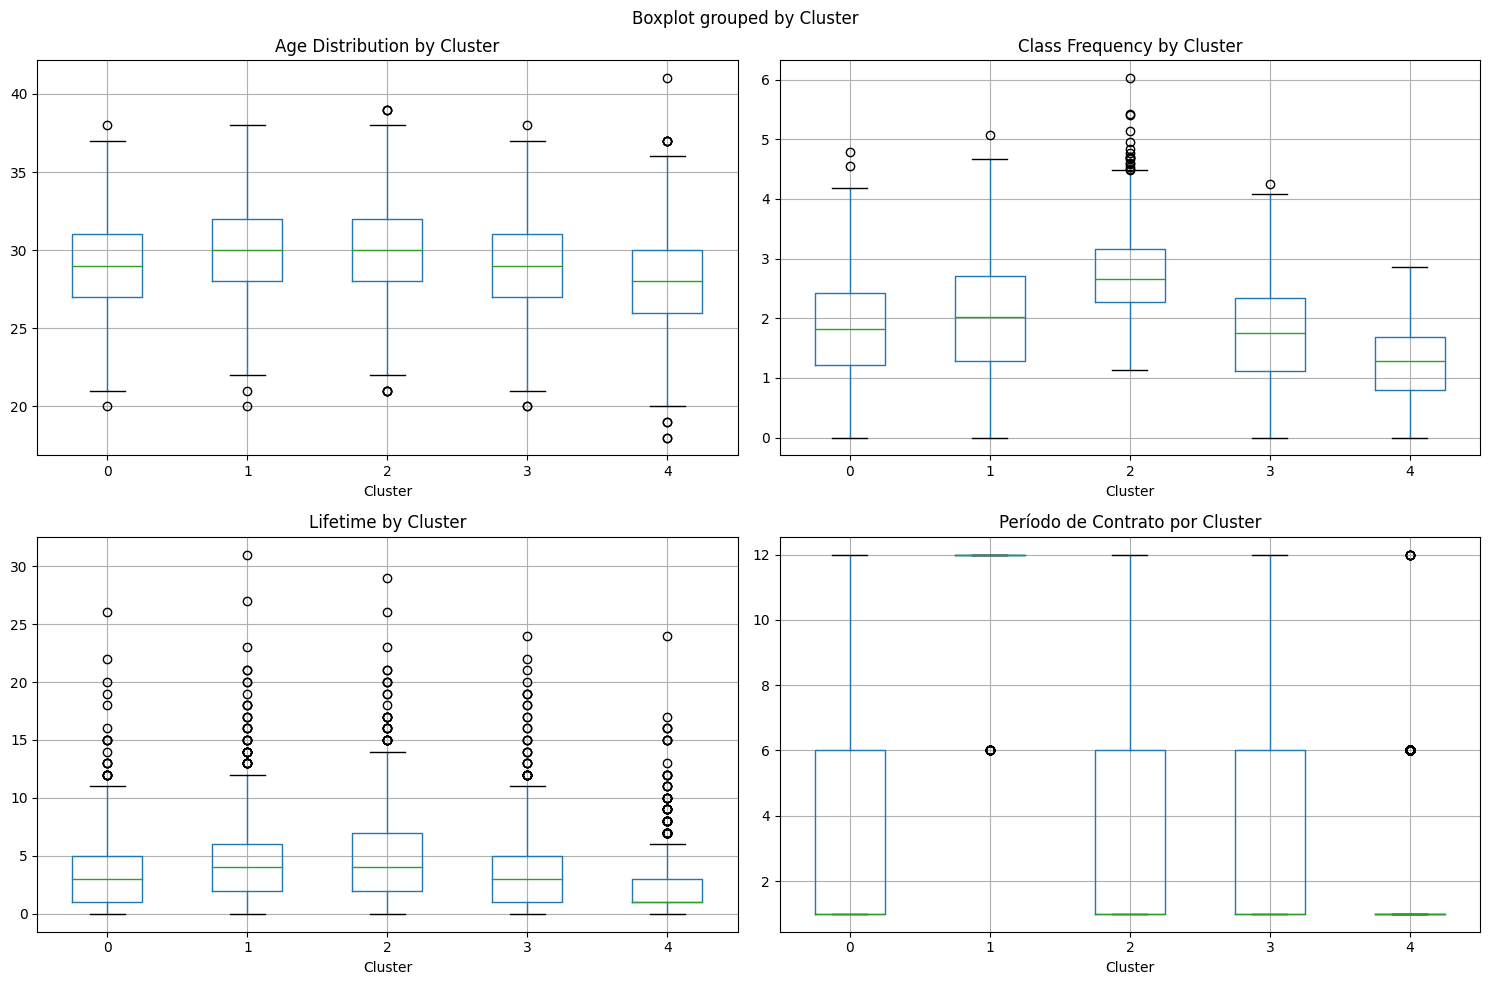

In [5]:
# Step 4 Clustering
# linkage metod
linked = linkage(X_train_st, method='ward')
dendrogram(linked)

# Graph Denogram
plt.figure(figsize=(12, 8))
dendrogram(linked)
plt.title('Dendrogram -  Hierarchical Clustering')
plt.xlabel('Index sample')
plt.ylabel('Distance')
plt.show() 

# KMeans metod
kmeans = KMeans(n_clusters=5, random_state=42) 
clusters = kmeans.fit_predict(X_train_st)

# Silhouette score 
silhouette_avg = silhouette_score(X_train_st, clusters)
print(f'Silhouette score: {silhouette_avg:.2f}')

# Aplicar clustering a TODO el dataset
all_data_scaled = scaler.transform(X)
all_clusters = kmeans.predict(all_data_scaled)

# Agregate clusters to dataframe
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = all_clusters

# Análisis de valores medios por cluster
cluster_means =
 df_with_clusters.groupby('Cluster').mean()
print("Valores medios por cluster:")
print(cluster_means)


# Most important caracteristics
important_features = ['Age', 'Avg_class_frequency_total', 'Lifetime', 'Contract_period']
print("\n Important Caracteristics per cluster:")
print(cluster_means[important_features])

# Distribution per cluster
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age per cluster
df_with_clusters.boxplot(column='Age', by='Cluster', ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Cluster')

# Clases frequency per cluster
df_with_clusters.boxplot(column='Avg_class_frequency_total', by='Cluster', ax=axes[0,1])
axes[0,1].set_title('Class Frequency by Cluster')

# Liftime per cluster
df_with_clusters.boxplot(column='Lifetime', by='Cluster', ax=axes[1,0])
axes[1,0].set_title('Lifetime by Cluster')

# Contract per cluster
df_with_clusters.boxplot(column='Contract_period', by='Cluster', ax=axes[1,1])
axes[1,1].set_title('Contract period per Cluster')
plt.tight_layout()
plt.show()


# Step 5 Conclusions
Considering the data and the analysis of the machine learning models applied in this project, we can observe that within the 5 groups, data is quite homogeneous in many of its characteristics, such as the average age and gender of the people in all of them. Age which ranges from 28 to 30 years, that is, 29 years average. However reagarding to churn rate, we can divide the 5 groups into 3 categories. Groups 1 and 2 have very low average churn rates of 2.2% and 8.5% respectively, indicating low risk, followed by groups 3 and 0, which have medium churn rates of 24.9% and 26.7% respectively. Finally, group 4, being the high-risk group for cancellation with an average of 57%, although in several cases it is not so easy to draw conclusions based on characteristics, since we can find contrasting values between groups when trying to correlate them with the churn rate. 
For example, for the promo_friend characteristic, group 3 has the highest value at 99.84%, which suggests a significant impact from friend recommendations, but it is not conclusive since group 2, being second in terms of lowest churn rate, has the second lowest value at 5%, only after group 4 (with the worst churn rate), which is expected at 1.61%. However, it is not a characteristic that improves the churn rate in all cases, although it undeniably has some impact, albeit not a significant one.

Characteristics that we can observe with direct implications for business use, the recommendation is to make greater efforts to integrate members into group visits ie training sessions. This characteristic has an impact on customer retention at the gym, as human relationships within a community generate powerful bonds that act as magnets to keep them motivated to exercise and become regular customers. Specifically, in the data, in almost all groups with low and medium churn rates, the indicator is high and very low compared to the indicator for group 4.

Avg_class_frequency_current_month, affecting Lifetime and Contract_period, is relevant to retention too. Another factor detected in the data regarding proximity to branches is that in all low-medium churn rate groups, it is between 84-94% near location customers, and in the high-risk cancellation group, it drops to only 74%, which hinders attendance and long-term retention. It would be beneficial to segment based on proximity to branches and focus the strategy on locations in areas with high population density to increase retention with more prospects near gym.